In [1]:
import HeatCurrentFunctions as QH
import matplotlib
matplotlib.rcParams['text.usetex'] = False

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc

# Collective Operators for Even (+1) Case
Jm_h = QH.sm1 + QH.sm2 
Jp_h = QH.sp1 + QH.sp2

# Collective Operators for Even (-1) Case
Jm_c = QH.sm1 - QH.sm2
Jp_c = QH.sp1 - QH.sp2

w0 = 1          # LC resonator frequency (sets the unit scale)
Qf = 7.1798      # Resonator quality factor

# Bath coupling strengths
gamma_h   = 0.0075   # Hot bath
gamma_c   = 0.0075   # Cold bath
gamma_local = 0.001 #0.001   # Parasitic relaxation
gamma_deph  = 0 # Pure dephasing (σ_z)
phase_factor_p = [-1, -1j, 1j, 1]
phase_factor_n = [-1, -0.9, -0.8, -0.5]

# Temperatures  (ℏ = k_B = 1)
T_local = 0.186    # Parasitic bath, 50 mK
T_h     = 1.2087    # Hot bath, 350 mK
T_c     = 0.186   # Cold bath, 50 mK
N= 51
#R = 10

# Diagnostic: effective temperature of the composite resonator bath
Ts = QH.T_star(T_c, gamma_c, T_h, gamma_h, w0)
print("T* =", Ts)

T* = 0.7877024107695236


In [3]:
# -------------------------------------------------------------------
# Frequency grid and heat-current maps
# -------------------------------------------------------------------
w_vals = np.linspace(0.5, 1.5, N)
W1, W2 = np.meshgrid(w_vals, w_vals)

Q_ind   = np.zeros((N,N, 4)) #np.zeros_like(W1)               # independent current
#Q_coll_sup  = np.zeros((N,N, 4)) #np.zeros_like(W1)           # even (+1) case current
Q_coll_sub = np.zeros((N,N, 4))            # odd case current
#Ratio_sup   = np.zeros((N,N, 4))           # enhancement factor even (+1) case
Ratio_sub   = np.zeros((N,N, 4))           # suppression factor odd case
#Q_coll_sup_even = np.zeros((N,N, 4))       # even (+1) case current   
#Ratio_sup_even = np.zeros((N,N, 4))   
'''
Lambda_sup  = np.zeros((N,N, 4))           # minimum eigenvalue (positivity check) for even (+1) case
Lambda_sub =  np.zeros((N,N, 4))           # minimum eigenvalue (positivity check) for odd case
Rho_ind = np.zeros((N,N, 4))               # storing off diagonal coherent terms for the independent case 
Rho_coll_sup_2 = np.zeros((N, N, 4,4))    # storing the steady state density matrix for the even (+1) case 
Rho_coll_sub_2 = np.zeros((N, N, 4,4))    # storing the steady state density matrix for the odd case 
Rho_coll_sup = np.zeros((N,N, 4))          # storing off diagonal coherent terms for the even (+1) case       
Rho_coll_sub = np.zeros((N,N, 4))          # storing off diagonal coherent terms for the odd case     
Rho_coll_sup_even = np.zeros((N, N, 4,4)) # storing the steady state density matrix for the Even (-1) case 
Q_coll_sup_even = np.zeros((N,N, 4))       # even (+1) case current      
Lambda_sup_even = np.zeros((N,N, 4))       # minimum eigenvalue (positivity check) for even (-1) case
Ratio_sup_even = np.zeros((N,N, 4))        # enhancement factor even (-1) case
'''
for i, w1 in enumerate(w_vals):
    for j, w2 in enumerate(w_vals):
        for k, p in enumerate(phase_factor_p):


            # Independent-bath steady state and current
            rho_ind = QH.rho_ss_termic_indepentend(
                w1, w2,
                gamma_local, T_local, gamma_deph,
                T_h, gamma_h, T_c, gamma_c,
                w0, Qf
            )
            #Rho_ind[j, i] = np.real(rho_ind[1][1])
            Q_ind[j, i, k] = QH.Current_ind(w1, w2, rho_ind, T_h, gamma_h, w0, Qf)

        
            
            # Collective-bath steady state and current, odd case
            rho_coll_sub = QH.rho_ss_termic_collective_sub(
                w1, w2,
                gamma_local, T_local, gamma_deph,
                T_h, gamma_h, T_c, gamma_c,
                w0, Qf, p
            )
            #Rho_coll_sub[j, i] = np.real(rho_coll_sub[1][2])
            #Rho_coll_sub_2[j, i, :, :] = np.real(rho_coll_sub.full())
            #print(rho_coll_sub.full())
            Q_coll_sub[j, i, k] = QH.Current_coll(w1, w2, rho_coll_sub, T_h, gamma_h, w0, Qf, Jm_h, Jp_h)

            # Diagnostics
            #Lambda_sub[j, i] = np.min(np.linalg.eigvalsh(rho_coll_sub.full()))
            Ratio_sub[j, i, k]  = Q_coll_sub[j, i, k] / Q_ind[j, i, k]

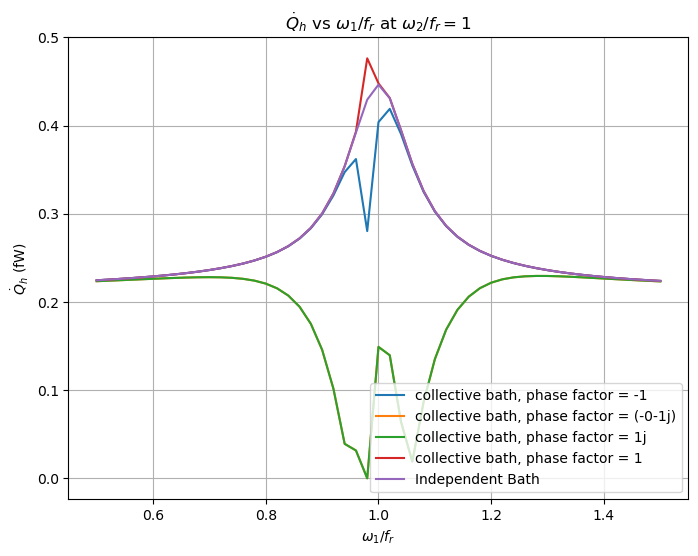

In [4]:
plt.figure(figsize=(8, 6))
for i, p in enumerate(phase_factor_p):
    plt.plot(w_vals, np.abs(130.559162011*Q_coll_sub[:, 24, i]), label = f"collective bath, phase factor = {p}")
plt.plot(w_vals, 130.559162011*Q_ind[:, 24, 0], label = "Independent Bath")
plt.xlabel(r'$\omega_1/f_r$')
plt.ylabel(r'$\dot{Q}_h$ (fW)')
plt.title(r'$\dot{Q}_h$ vs $\omega_1/f_r$ at $\omega_2/f_r = 1$')
plt.legend()
plt.grid(True)
plt.show()

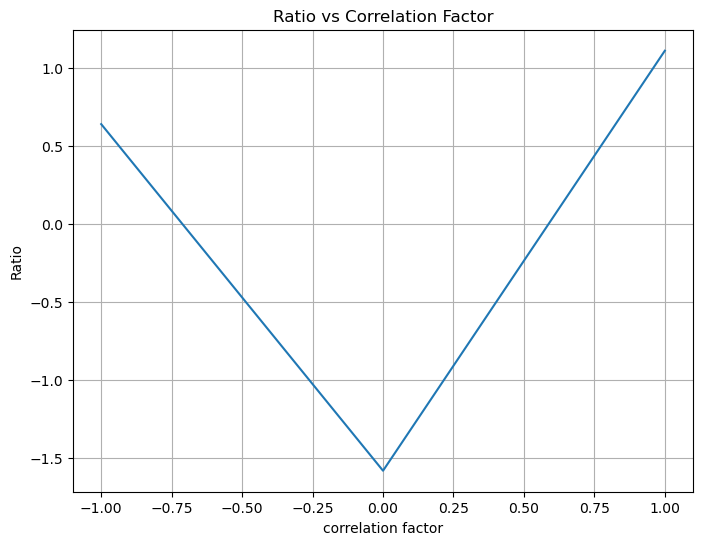

In [27]:
plt.figure(figsize=(8, 6))
ratios = [np.min(Ratio_sub[:, :, 0]), np.min(Ratio_sub[:, :, 1]), np.min(Ratio_sub[:, :, 2]), np.max(Ratio_sub[:, :, 3])]
plt.plot(phase_factor_p, ratios)
plt.xlabel(r'correlation factor')
plt.ylabel(r'Ratio')
plt.title(r'Ratio vs Correlation Factor')
plt.grid(True)
plt.show()

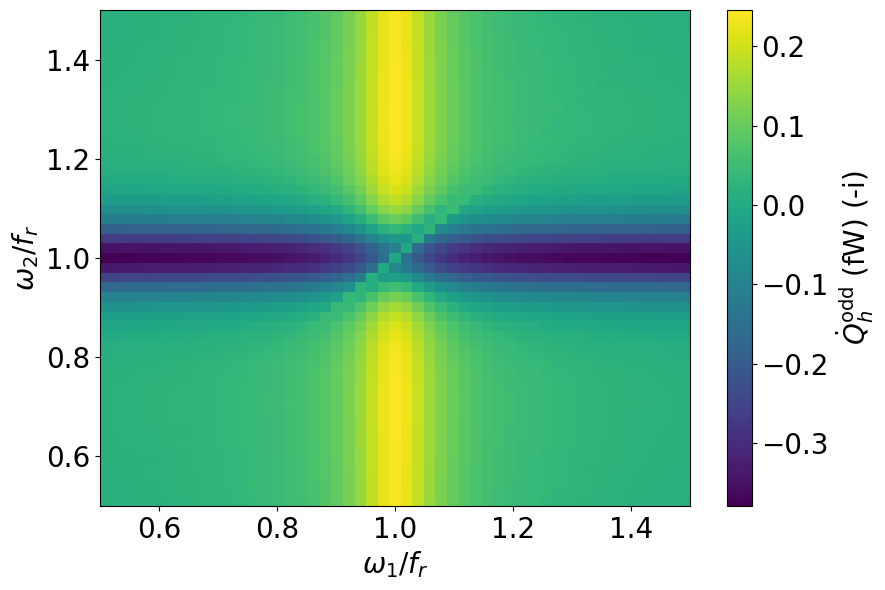

In [29]:
plt.figure(figsize=(9, 6))
#rc('text',usetex=True)

cp = plt.imshow(
    130*(Q_coll_sub[:,:, 1]),  # negative heat current for display
    extent=(w_vals.min(), w_vals.max(), w_vals.min(), w_vals.max()),
    aspect='auto',
    origin='lower'
)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.xlabel(r'$\omega_1/f_r$', fontsize=20)
plt.ylabel(r'$\omega_2/f_r$', fontsize=20)

cbar = plt.colorbar(cp)
# Imposto la label con fontsize
cbar.set_label(r'$\dot Q_h^{\rm odd}$ (fW) (-i)', fontsize=20)
# Regolo la dimensione dei tick
cbar.ax.tick_params(labelsize=20)
plt.tight_layout()

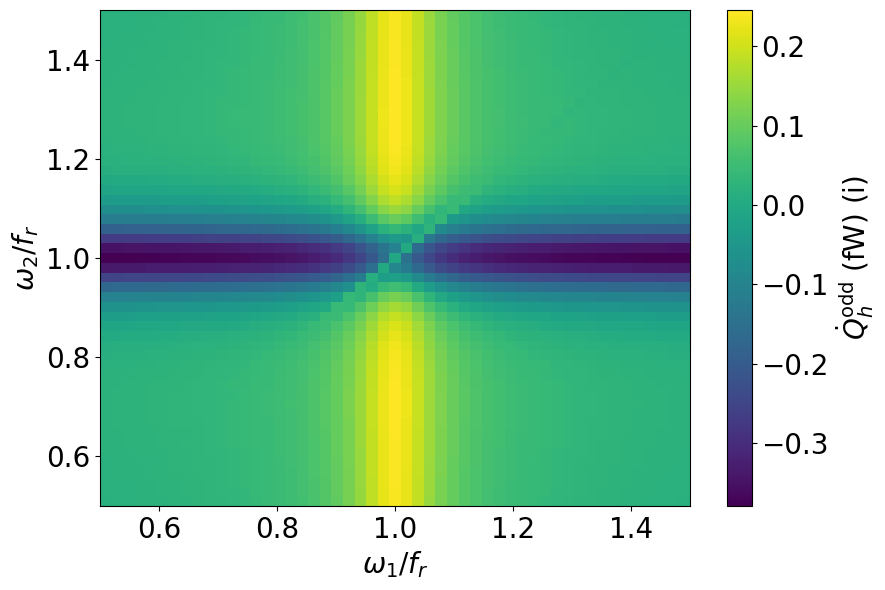

In [30]:
plt.figure(figsize=(9, 6))
#rc('text',usetex=True)

cp = plt.imshow(
    130*(Q_coll_sub[:,:, 2]),  # negative heat current for display
    extent=(w_vals.min(), w_vals.max(), w_vals.min(), w_vals.max()),
    aspect='auto',
    origin='lower'
)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.xlabel(r'$\omega_1/f_r$', fontsize=20)
plt.ylabel(r'$\omega_2/f_r$', fontsize=20)

cbar = plt.colorbar(cp)
# Imposto la label con fontsize
cbar.set_label(r'$\dot Q_h^{\rm odd}$ (fW) (i)', fontsize=20)
# Regolo la dimensione dei tick
cbar.ax.tick_params(labelsize=20)
plt.tight_layout()